trackbar in OpenCV with high gui 

episode 6 

In [3]:
# import neccessary libraries
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 as cv 
import os 

In [15]:
# dynamic path 
current_path = os.getcwd()
project_dir = os.path.dirname(current_path)
image_dir = os.path.join(project_dir, 'images')

In [16]:
im1_name = 'class.vision.jpg'
im2_name = 'opencv.jpg'

im1_path = os.path.join(image_dir, im1_name)
im2_path = os.path.join(image_dir, im2_name)

# add weighted and show images which added together  
im1 = cv.imread(im1_path)
im2 = cv.imread(im2_path)

Text(0.5, 1.0, '0.47')

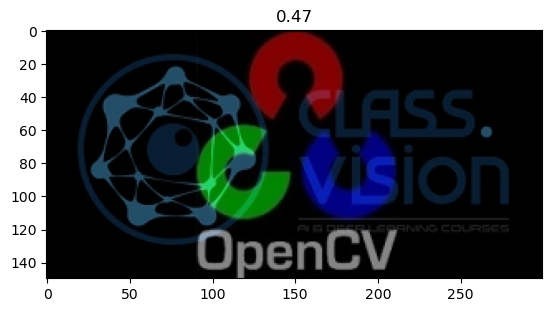

In [ ]:
# add weighted two images and changeing by user 
max_alpha_slider = 100
def trackbar_creating(val) : 
    global max_alpha_slider, alpha, im3
    alpha = val / max_alpha_slider
    beta = 1.0 - alpha 
    im3 = cv.addWeighted(im1, alpha, im2, beta, 0.0)
    cv.imshow('image', im3)

cv.namedWindow('image')
cv.createTrackbar('alpha', 'image', 0, max_alpha_slider, trackbar_creating)
trackbar_creating(0)
cv.waitKey()
cv.destroyAllWindows()
plt.imshow(im3[..., ::-1])
plt.title(alpha)
    

In [ ]:
# for change colors on an image
def nothing(x) : 
    pass
im3 = np.zeros((512, 512, 3), np.uint8)
cv.namedWindow('image')
cv.createTrackbar('red', 'image', 0, 255, nothing)
cv.createTrackbar('green', 'image', 0, 255, nothing)
cv.createTrackbar('blue', 'image', 0, 255, nothing)

while True:
    cv.imshow('image',im3)
    if cv.waitKey(1) & 0xFF ==27:
        break
    # get current positions of four trackbars
    r = cv.getTrackbarPos('red','image')
    g = cv.getTrackbarPos('green','image')
    b = cv.getTrackbarPos('blue','image')
    im3[:] = [b,g,r]

cv.destroyAllWindows()

practice 6 episode 7

In [ ]:
# to create a simple program like paint 
def nothing(x):
    pass

drawing = False
last_point = None  
r, g, b, thickness = 0, 0, 0, 1

def plot_line(event, x, y, flags, param):
    global drawing, last_point, r, g, b, thickness
    current_point = (x, y)
    if event == cv.EVENT_LBUTTONDOWN:
        drawing = True
        last_point = current_point
    elif event == cv.EVENT_MOUSEMOVE:
        if drawing:
            if last_point:
                cv.line(im3, last_point, current_point, (b, g, r), thickness)
            last_point = current_point
    elif event == cv.EVENT_LBUTTONUP:
        drawing = False
        last_point = None  

im3 = np.zeros((512, 512, 3), np.uint8)
cv.namedWindow('image')
cv.setMouseCallback('image', plot_line)
cv.createTrackbar('red', 'image', 0, 255, nothing)
cv.createTrackbar('green', 'image', 0, 255, nothing)
cv.createTrackbar('blue', 'image', 0, 255, nothing)
cv.createTrackbar('thickness', 'image', 1, 10, nothing)

while True:
    cv.imshow('image', im3)
    if cv.waitKey(1) & 0xFF == 27:
        break
    # get current positions of four trackbars
    r = cv.getTrackbarPos('red', 'image')
    g = cv.getTrackbarPos('green', 'image')
    b = cv.getTrackbarPos('blue', 'image')
    thickness = cv.getTrackbarPos('thickness', 'image')

cv.destroyAllWindows()